# Calculate 2-point correlations as function of separation

We study **two-point correlation functions** of scalar fields on organoid surfaces.  
Each organoid is represented as a triangular mesh. Distances between vertices are computed using:

- **Heat method (Crane et al. 2013):** smooth geodesic approximation.  
- **Dijkstra (graph geodesic):** shortest path along mesh edges, used for comparison.  

To make correlations efficient:  
1. **Coarse-grain** vertices with farthest-point sampling.  
2. **Precompute distance bins** between vertex pairs.  
3. **Accumulate correlations per bin**, weighted by vertex areas.  

This yields normalized two-point functions of fields (e.g. HKS), revealing characteristic length scales of variation across the organoid surface.


In [1]:
from src.fatemarkers import FateMarkers

import matplotlib
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from nonlocal_correlations import *

## Load organoid mesh and build laplacian

For illustration purposes we just treat a single organoid 

In [2]:
data_dir = '../NicoleData/20250714/fractal_output'

# choose one timepoint/well/round
timepoint = "day4p5"
zarr_name = "r0.zarr"
well = "A06"
round_name = "0_fused_zillum"
organoid_id = 19  # example


path = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_linked_annotated/{organoid_id}.vtp"


m = FateMarkers()
m.load_mesh_from_file(path)
m.align_with_pca()
_ = m.compute_coefficients(lmax=15)    # must populate m.eigvals, m.eigvecs
L, M = build_cotangent_laplacian_and_mass(m.v, m.f)

print(m.v.shape)

(18001, 3)


In [ ]:
from scipy import sparse

# Example with L or M
L = -igl.cotmatrix(m.v, m.f)
M = igl.massmatrix(m.v, m.f, igl.MASSMATRIX_TYPE_VORONOI)

# Number of nonzeros
nnz_L = L.nnz
nnz_M = M.nnz

# Sparsity fraction
frac_L = nnz_L / (L.shape[0] * L.shape[1])
frac_M = nnz_M / (M.shape[0] * M.shape[1])

print(f"L: {nnz_L} nonzeros, sparsity fraction = {frac_L:.6f}")
print(f"M: {nnz_M} nonzeros, sparsity fraction = {frac_M:.6f}")

In [3]:
hks = m.compute_hks_for_new_times(new_ts=[4.0], coeffs=False)
print(hks.shape)

fig = go.Figure(data=[
    go.Mesh3d(
        x=m.v[:,0], y=m.v[:,1], z=m.v[:,2],
        i=m.f[:,0], j=m.f[:,1], k=m.f[:,2],
        intensity=hks,
        colorscale='Viridis',
        showscale=True,   # adds colorbar
        name="Surface"
    )
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    title="Heat kernel signature"
)

fig.show()

(18001, 1)


In [4]:
vertex_fields = np.concatenate([hks, m.fields[:,3:]], axis=1)

Additionally we calculate the Voronoi area weight per vertex, which can be done directly from the mass matrix

In [5]:
vertex_areas = np.array(M.diagonal())


# for comparison compute face areas directly
tri = m.v[m.f]
face_areas = 0.5 * np.linalg.norm(np.cross(tri[:,1] - tri[:,0], tri[:,2] - tri[:,0]), axis=1)

total_face_area = face_areas.sum()
total_vertex_area = vertex_areas.sum()

print("Total face area:   ", total_face_area)
print("Total vertex area: ", total_vertex_area)

Total face area:    380.45227
Total vertex area:  380.4522652494743


## Coarse-grain to cell-level

To limit the computations needed for calculating correlations, we coarse-grain the vertex mesh, selecting the surface centroid of each cell. Additionally, we compute some quantities averaged over the surface area of each cell.

Note, for computing geodesic distances between the coarse-grained points, we still need the full mesh.

In [6]:
def get_patch_centers(vertices, labels):
    """
    For each patch (unique label), compute the 'center' vertex index:
      - compute centroid of all vertices in patch
      - pick vertex in patch closest to this centroid
    
    Args:
        vertices: (V,3) ndarray of vertex coordinates
        labels: (V,) ndarray of integer patch labels
    
    Returns:
        unique_labels: (P,) ndarray of sorted unique labels
        centers_idx: (P,) ndarray of vertex indices (into vertices)
    """
    unique_labels = np.unique(labels)
    centers_idx = np.empty(len(unique_labels), dtype=int)

    for i, lbl in enumerate(unique_labels):
        mask = labels == lbl
        patch_vertices = vertices[mask]

        # centroid of patch vertices
        centroid = patch_vertices.mean(axis=0)

        # indices of patch vertices in global array
        patch_indices = np.nonzero(mask)[0]

        # find vertex closest to centroid
        diffs = vertices[patch_indices] - centroid
        dists = np.einsum("ij,ij->i", diffs, diffs)  # squared distances
        best_idx = patch_indices[np.argmin(dists)]

        centers_idx[i] = best_idx

    return unique_labels, centers_idx

In [7]:
def remap_labels_to_contiguous(labels):
    """
    labels: (V,) int array, may contain negative -1 for unlabeled vertices.
    returns:
      labels_contig: (V,) ints in -1 or [0..C-1]
      mapping: dict old_label -> new_index
    """
    labs = np.asarray(labels)
    uniq = np.unique(labs[labs >= 0])
    mapping = {int(old): new for new, old in enumerate(uniq)}
    labels_contig = np.full_like(labs, -1)
    for old, new in mapping.items():
        labels_contig[labs == old] = new
    return labels_contig, mapping


def per_cell_stats_from_vertex_labels(v, f, vertex_areas, vertex_cell_labels, vertex_fields):
    # remap labels first
    labels, mapping = remap_labels_to_contiguous(vertex_cell_labels)
    V = v.shape[0]
    vf = np.asarray(vertex_fields)
    if vf.ndim == 1:
        vf = vf[:, None]
    C = int(labels.max() + 1) if (labels >= 0).any() else 0

    weighted_pos = np.zeros((C, 3), dtype=float)
    weighted_field = np.zeros((C, vf.shape[1]), dtype=float)
    cell_area_v = np.zeros(C, dtype=float)
    counts = np.zeros(C, dtype=int)

    for idx in range(V):
        lab = int(labels[idx])
        if lab < 0:
            continue
        a = float(vertex_areas[idx])
        weighted_pos[lab] += a * v[idx]
        weighted_field[lab] += a * vf[idx]
        cell_area_v[lab] += a
        counts[lab] += 1

    valid = cell_area_v > 0
    centroids = np.zeros((C, 3), dtype=float)
    fields = np.zeros((C, vf.shape[1]), dtype=float)
    centroids[valid] = weighted_pos[valid] / cell_area_v[valid, None]
    fields[valid] = weighted_field[valid] / cell_area_v[valid, None]

    return centroids, cell_area_v, fields, valid, labels

In [8]:

_, patch_centers = get_patch_centers(m.v, m.fields[:,0])

centroids, cell_areas, cell_weighted_fields, valid, cell_labels = per_cell_stats_from_vertex_labels(m.v, m.f, vertex_areas, m.fields[:,0], vertex_fields)

print(patch_centers.shape)  # {label: vertex_index}
print(centroids.shape)

V = m.v.shape[0]
S = patch_centers.shape[0] # subset size 

(562,)
(562, 3)


In [9]:
fig = go.Figure(data=[
    go.Mesh3d(
        x=m.v[:,0], y=m.v[:,1], z=m.v[:,2],
        i=m.f[:,0], j=m.f[:,1], k=m.f[:,2],
        intensity=m.fields[:,0],
        colorscale='Viridis',
        showscale=True,   # adds colorbar
        name="Surface"
    ),
    go.Scatter3d(
        # x=centroid_coords[:,0], y=centroid_coords[:,1], z=centroid_coords[:,2],
        x=m.v[patch_centers,0], y=m.v[patch_centers,1], z=m.v[patch_centers,2],
        mode='markers',
        marker=dict(size=6, color='red', symbol='circle'),
        name="Source vertex"
    ),
    go.Scatter3d(
        # x=centroid_coords[:,0], y=centroid_coords[:,1], z=centroid_coords[:,2],
        x=centroids[:,0], y=centroids[:,1], z=centroids[:,2],
        mode='markers',
        marker=dict(size=6, color='blue', symbol='circle'),
        name="Centroid coordinates"
    )
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    title="Patch centers"
)

fig.show()


## Calculate geodesics

In [10]:
# Calculate geodesics using heat method (Crane et al. 2013)
dist_heat_all = heat_geodesic_all_sources(m.v, m.f, L, M, t=None, sources=patch_centers)  # (S,V)

heat sources: 100%|██████████| 562/562 [00:02<00:00, 229.58it/s]


In [11]:
# For comparison we calculate distances with Dijkstra
edge_graph = build_edge_graph(m.v, m.f)
dist_graph_all = geodesic_dijkstra_all_sources(edge_graph, sources=patch_centers)

In [12]:
# select just the subset pairs
dist_heat = dist_heat_all[:, patch_centers] # (S,S)
dist_graph = dist_graph_all[:, patch_centers]

# get upper upper triangle (i<j, no duplicate vertex pairs) and flatten into vector 
iu, ju = np.triu_indices(S, k=1)
d_heat_pairs =  dist_heat[iu, ju]
d_graph_pairs = dist_graph[iu, ju]


print(dist_heat_all.shape)
print(dist_heat.shape)
print(d_heat_pairs.shape)

(562, 18001)
(562, 562)
(157641,)


Plotting the geodesic distances vs graph distances, shows similar distribution but the latter having larger values. This is to be expected, as Dijkstra calculates cummulative distance through the edges, while the heat method approximates the geodesics.

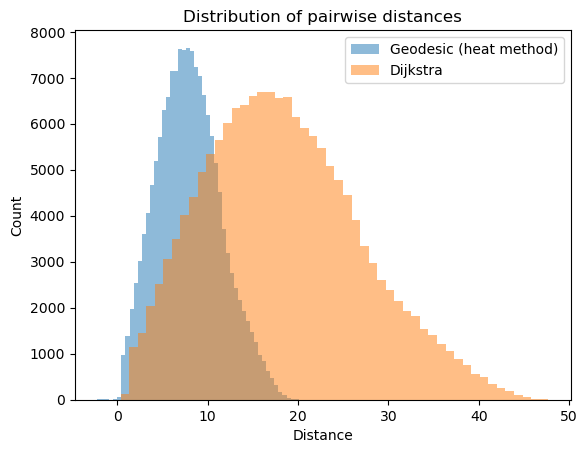

In [13]:
plt.hist(d_heat_pairs, bins=50, alpha=0.5, label="Geodesic (heat method)")
plt.hist(d_graph_pairs, bins=50, alpha=0.5, label="Dijkstra")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.legend()
plt.title("Distribution of pairwise distances")
plt.show()

As a sanity check, we can plot the distance to a single point for both methods. Given the size of the organoid, it should be evident that Dijkstra gives way too large values.

In [14]:
src_idx = 42  # single heat source

fig = go.Figure(data=[
    go.Mesh3d(
        x=m.v[:,0], y=m.v[:,1], z=m.v[:,2],
        i=m.f[:,0], j=m.f[:,1], k=m.f[:,2],
        intensity=dist_heat_all[src_idx, :],
        colorscale='Viridis',
        showscale=True,   # adds colorbar
        name="Surface"
    ),
    go.Scatter3d(
        x=[m.v[patch_centers[src_idx],0]], y=[m.v[patch_centers[src_idx],1]], z=[m.v[patch_centers[src_idx],2]],
        mode='markers',
        marker=dict(size=6, color='red', symbol='circle'),
        name="Source vertex"
    )
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    title="Geodesic distances (Heat method)"
)

fig.show()


## Calculate 2-point correlation functions

The distances obtained with the heat method are binned, then correlations are computed for each bin 

In [15]:
# --- binning parameters ---
dmax = 0.99*np.max(d_heat_pairs)
nbins = 64
bin_edges = np.linspace(0.0, dmax, nbins + 1)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])

bins_dist_weighted = pair_bins_from_distances(dist_heat, cell_areas, bin_edges, use_area_weights=True)
bins_dist_equal = pair_bins_from_distances(dist_heat, cell_areas, bin_edges, use_area_weights=False)


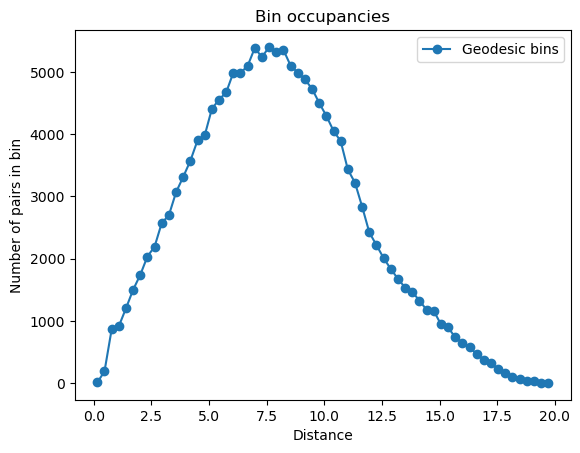

In [16]:
counts_dist = [len(bins_dist_weighted[f"I_{b}"]) for b in range(len(bin_edges)-1)]

plt.plot(bin_centers, counts_dist, 'o-', label="Geodesic bins")
plt.xlabel("Distance")
plt.ylabel("Number of pairs in bin")
plt.legend()
plt.title("Bin occupancies")
plt.show()

## Calculate correlations on cell grid

The first step is to figure out the correct normalization for the fields and the correlations. 

Let bin $b$ contain unordered pairs $(i,j)$, with $i < j$, chosen such that the geodesic distance $d(i,j)$ lies within the range of the bin. The two-point correlation of fields $F^k$ and $F^l$ can then be calculated within a given bin using:

**Surface-integral (area-weighted) approach**
$$ C_b^{k l} = Z_b^{-1} \sum_{(i,j)\in r} a_i a_j F_i^k F_j^l$$
where $Z_b = \sum_{(i,j)\in r} a_i a_j$ and $a_i$ is the surface area of surface area associated to sample $i$.


**Lattice (equal-weight) approach**
$$ C_b^{k l} = N_b^{-1} \sum_{(i,j)\in r}  F_i^k F_j^l$$
where $N_b$ is the number of unordered pairs in bin $b$.


If cell areas are nonuniform, the lattice estimator equals the area-weighted estimator only if either
1. $a_i \approx \mathrm{const}$ (which is the case for fate markers), or
2. the field $\mathbf{F}$ is uncorrelated with $\mathbf{a}$ (i.e. the distribution of $\mathbf{F}$ is independent of cell area)
Otherwise the lattice estimator is a biased approximation to the surface integral.


** Connected correlations**
The raw two-point correlation C_b^{kl} contains both genuine correlations and a trivial baseline from the global means.  
To isolate fluctuations, we define the connected correlation:

$$C_{b,conn}^{kl} = C_b^{kl} - \mu^k \mu^l $$

with global means

- Surface (area-weighted): $\mu^k = (\sum_i a_i F_i^k) / (\sum_i a_i)$  
- Lattice (equal-weight): $\mu^k = (1/V) \sum_i F_i^k $

Normalization difference:  
- Raw C_b^{kl} is normalized per-bin (Z_b or N_b).  
- The subtraction uses global means, independent of bin.  

Thus, uncorrelated fields yield C_{b,conn}^{kl} ≈ 0, while any nontrivial spatial structure remains visible.


**In this section**

To determine which approach is best, we run a few tests:

1. Compare area-weighted and equal-weighted correlation for **synthetic fields**
2. Compare for the **physical fields** (here just for a single organoid)


### Generate synthetic scalar field for correlation testing

In [17]:
def generate_sinusoidal_field(v: np.ndarray, k: float = 5.0, direction: np.ndarray = None) -> np.ndarray:
    """
    Generate a synthetic sinusoidal scalar field on a mesh.
    
    Args:
        v : ndarray (V,3)
            Vertex coordinates.
        k : float
            Wavenumber. Higher k = shorter wavelength.
        direction : ndarray (3,), optional
            Direction vector along which to define the sinusoid.
            Defaults to x-axis.
    
    Returns:
        field : ndarray (V,)
            Scalar field values at each vertex.
    """
    if direction is None:
        direction = np.array([1.0, 0.0, 0.0])
    direction = direction / np.linalg.norm(direction)
    
    # Project vertices onto direction
    proj = v @ direction
    # Sine wave along that direction
    field = np.sin(k * proj)
    return field


def generate_gaussian_bump_field(v: np.ndarray, center_idx: int = 0, sigma: float = 0.1) -> np.ndarray:
    """
    Generate a localized Gaussian bump field on the mesh.
    
    Args:
        v : ndarray (V,3)
            Vertex coordinates.
        center_idx : int
            Index of vertex to use as Gaussian center.
        sigma : float
            Width (standard deviation) of the Gaussian in Euclidean space.
    
    Returns:
        field : ndarray (V,)
            Scalar field values at each vertex.
    """
    center = v[center_idx]
    dists = np.linalg.norm(v - center[None,:], axis=1)
    field = np.exp(-0.5 * (dists / sigma)**2)
    return field


In [18]:
# Generate a synthetic test field on the organoid
field_sin = generate_sinusoidal_field(m.v, k=3.0)        # sinusoidal
field_gauss = generate_gaussian_bump_field(m.v, center_idx=500, sigma=6.0) # Gaussian bump


fig = go.Figure(data=[
    go.Mesh3d(
        x=m.v[:,0], y=m.v[:,1], z=m.v[:,2],
        i=m.f[:,0], j=m.f[:,1], k=m.f[:,2],
        intensity=field_sin,
        colorscale='Viridis',
        showscale=True,   # adds colorbar
        name="Surface"
    )
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    title="Synthetic field for correlation testing"
)

fig.show()

In [19]:
X = np.stack([field_sin[patch_centers], field_gauss[patch_centers]], axis=1)  # shape (V,2)

# Accumulate correlations
Cw_synth, Nw_synth = accumulate_correlations_from_bins(bins_dist_weighted, X) # compute surface area weighted correlations
Ce_synth, Ne_synth = accumulate_correlations_from_bins(bins_dist_equal, X) # compute equal weighted correlations

print(Cw_synth.shape)
print(Nw_synth.shape)

(64, 2, 2)
(64,)


In [20]:
# Number of fields (F)
F = Cw_synth.shape[1]

# --- compute means ---
# For equal-weight (lattice) use simple arithmetic mean over cells
mean_eq = np.nanmean(X, axis=0)   # shape (F,)

# For weighted (surface) means we use cell_areas if available
areas = np.asarray(cell_areas, dtype=float)
A_sum = np.sum(areas)
if A_sum <= 0:
    raise ValueError("cell_areas sum is zero or negative")
mean_w = (areas[:, None] * X).sum(axis=0) / A_sum


# --- subtract mean outer product to get connected correlations ---
def connected_from_C(C, mean_vec):
    """
    C: (B,F,F)
    mean_vec: (F,)
    returns C_conn: (B,F,F)
    """
    B = C.shape[0]
    C_conn = np.empty_like(C)
    mm = np.outer(mean_vec, mean_vec)  # (F,F)
    for b in range(B):
        if np.all(np.isnan(C[b])):
            C_conn[b] = np.full((F,F), np.nan)
        else:
            C_conn[b] = C[b] - mm
    return C_conn

Cw_synth_conn = connected_from_C(Cw_synth, mean_w)
Ce_synth_conn = connected_from_C(Cw_synth, mean_eq)

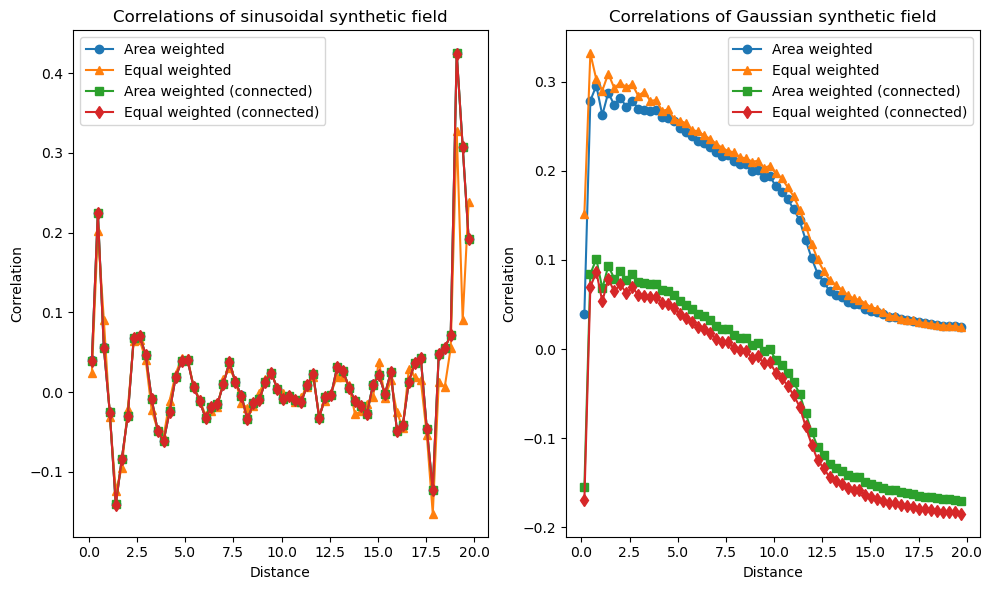

In [21]:
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
plt.plot(bin_centers, Cw_synth[:,0,0], 'o-', label="Area weighted")
plt.plot(bin_centers, Ce_synth[:,0,0], '^-', label="Equal weighted")
plt.plot(bin_centers, Cw_synth_conn[:,0,0], 's-', label="Area weighted (connected)")
plt.plot(bin_centers, Ce_synth_conn[:,0,0], 'd-', label="Equal weighted (connected)")
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Correlations of sinusoidal synthetic field")
plt.legend()

plt.subplot(1,2,2)
plt.plot(bin_centers, Cw_synth[:,1,1], 'o-', label="Area weighted")
plt.plot(bin_centers, Ce_synth[:,1,1], '^-', label="Equal weighted")
plt.plot(bin_centers, Cw_synth_conn[:,1,1], 's-', label="Area weighted (connected)")
plt.plot(bin_centers, Ce_synth_conn[:,1,1], 'd-', label="Equal weighted (connected)")
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Correlations of Gaussian synthetic field")
plt.legend()

plt.tight_layout()
plt.show()

### Auto-correlation of HKS

In [22]:
hks_raw = vertex_fields[patch_centers, 0] # raw value of HKS sampled at cell centroids
hks_cell = cell_weighted_fields[:, 0] # HKS weighted over the area of each cell

print(hks_raw.shape)
print(hks_cell.shape)

(562,)
(562,)


In [23]:
Cw_hks_raw, Nw_hks_raw = accumulate_correlations_from_bins(bins_dist_weighted, hks_raw) # compute surface area weighted correlations
Ce_hks_raw, Ne_hks_raw = accumulate_correlations_from_bins(bins_dist_equal, hks_raw) # compute equal weighted correlations

Cw_hks_cell, Nw_hks_cell = accumulate_correlations_from_bins(bins_dist_weighted, hks_cell) # compute surface area weighted correlations
Ce_hks_cell, Ne_hks_cell = accumulate_correlations_from_bins(bins_dist_equal, hks_cell) # compute equal weighted correlations

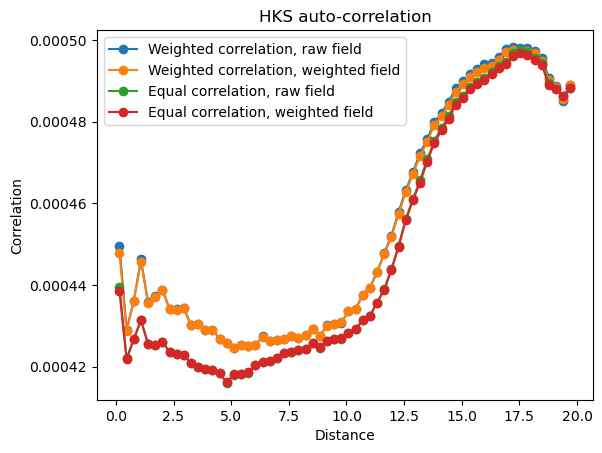

In [24]:
plt.plot(bin_centers, Cw_hks_raw[:,0,0], 'o-', label="Weighted correlation, raw field")
plt.plot(bin_centers, Cw_hks_cell[:,0,0], 'o-', label="Weighted correlation, weighted field")

plt.plot(bin_centers, Ce_hks_raw[:,0,0], 'o-', label="Equal correlation, raw field")
plt.plot(bin_centers, Ce_hks_cell[:,0,0], 'o-', label="Equal correlation, weighted field")

plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("HKS auto-correlation")
plt.legend()


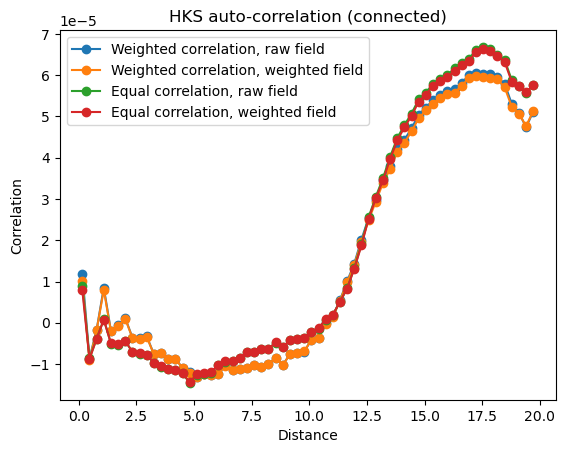

In [25]:
# If your HKS arrays are V-length vectors, make them (V,1)
def ensure_field_matrix(X):
    X = np.asarray(X)
    if X.ndim == 1:
        X = X[:, None]
    return X

# The per-cell HKS arrays used when building the Cs:
# - hks_raw: HKS sampled at centroids (shape (C,) or (C,1))
# - hks_cell: HKS averaged over cell patch (shape (C,) or (C,1))
hks_raw_m = ensure_field_matrix(hks_raw)
hks_cell_m = ensure_field_matrix(hks_cell)

# Number of fields (F)
F = Cw_hks_raw.shape[1]

# --- compute means ---
# For equal-weight (lattice) use simple arithmetic mean over cells
mean_eq_raw = np.nanmean(hks_raw_m, axis=0)   # shape (F,)
mean_eq_cell = np.nanmean(hks_cell_m, axis=0)

# For weighted (surface) means we use cell_areas if available
if 'cell_areas' in globals() or 'cell_areas' in locals():
    areas = np.asarray(cell_areas, dtype=float)
    A_sum = np.sum(areas)
    if A_sum <= 0:
        raise ValueError("cell_areas sum is zero or negative")
    mean_w = (areas[:, None] * hks_raw_m).sum(axis=0) / A_sum
    mean_w = (areas[:, None] * hks_cell_m).sum(axis=0) / A_sum
else:
    # Fallback: use arithmetic mean if no areas provided,
    # but this is not strictly area-weighted!
    mean_w = mean_eq_raw.copy()
    mean_w = mean_eq_cell.copy()
    print("Warning: cell_areas not found; using arithmetic mean for weighted means (not ideal).")

# --- subtract mean outer product to get connected correlations ---
def connected_from_C(C, mean_vec):
    """
    C: (B,F,F)
    mean_vec: (F,)
    returns C_conn: (B,F,F)
    """
    B = C.shape[0]
    C_conn = np.empty_like(C)
    mm = np.outer(mean_vec, mean_vec)  # (F,F)
    for b in range(B):
        if np.all(np.isnan(C[b])):
            C_conn[b] = np.full((F,F), np.nan)
        else:
            C_conn[b] = C[b] - mm
    return C_conn

Cw_hks_raw_conn = connected_from_C(Cw_hks_raw, mean_w)
Ce_hks_raw_conn = connected_from_C(Ce_hks_raw, mean_eq_raw)
Cw_hks_cell_conn = connected_from_C(Cw_hks_cell, mean_w)
Ce_hks_cell_conn = connected_from_C(Ce_hks_cell, mean_eq_cell)


plt.plot(bin_centers, Cw_hks_raw_conn[:,0,0], 'o-', label="Weighted correlation, raw field")
plt.plot(bin_centers, Cw_hks_cell_conn[:,0,0], 'o-', label="Weighted correlation, weighted field")

plt.plot(bin_centers, Ce_hks_raw_conn[:,0,0], 'o-', label="Equal correlation, raw field")
plt.plot(bin_centers, Ce_hks_cell_conn[:,0,0], 'o-', label="Equal correlation, weighted field")

plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("HKS auto-correlation (connected)")
plt.legend()

### Auto- and cross-correlations of all fields

Since the centroid-sampled and cell-area-averaged fields seem very similar, we proceed just using the former

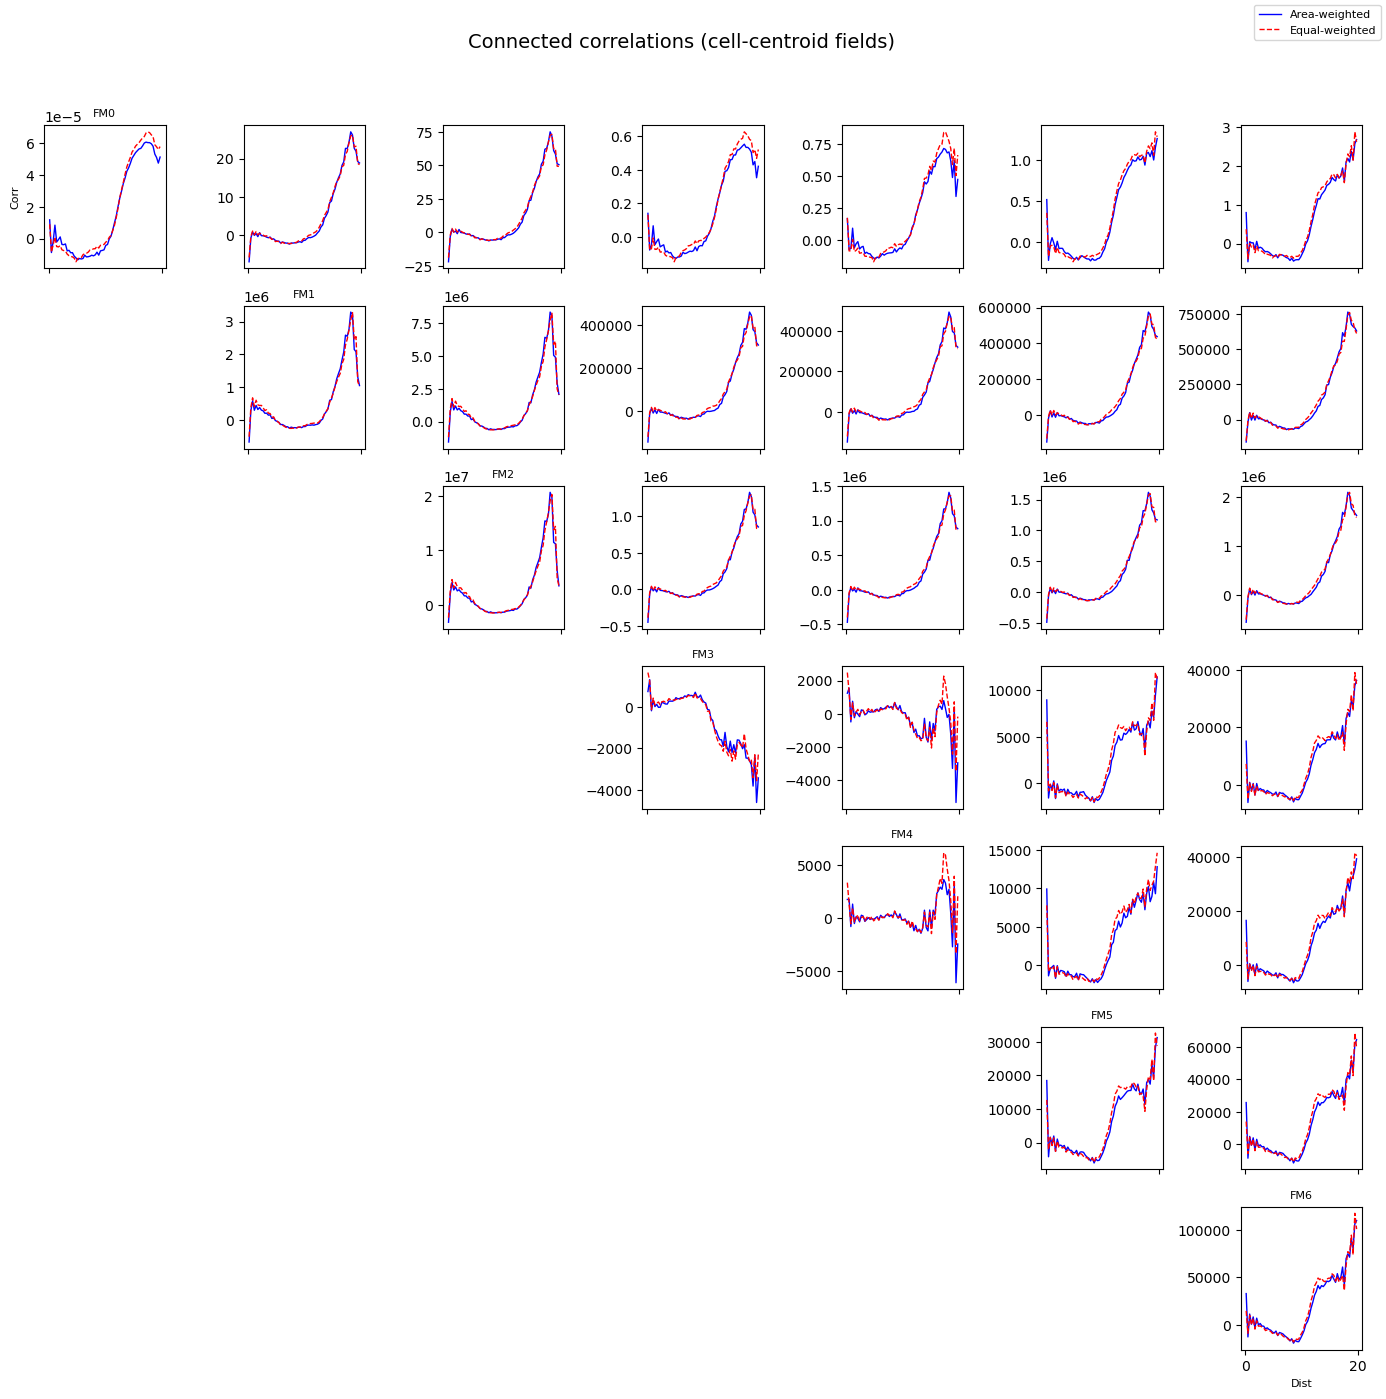

In [26]:
X = vertex_fields[patch_centers, :]

Cw_raw, Nw_raw = accumulate_correlations_from_bins(bins_dist_weighted, X) # compute surface area weighted correlations
Ce_raw, Ne_raw = accumulate_correlations_from_bins(bins_dist_equal, X) # compute equal weighted correlations


# --- compute connected correlations ---
F = X.shape[1]

# Global means (equal-weighted)
mean_eq = np.mean(X, axis=0)

# Area-weighted means (using cell areas)
mean_w = (cell_areas[:, None] * X).sum(axis=0) / areas.sum()

# Connected correlations: subtract global mean products
Cw_raw_conn = np.copy(Cw_raw)
Ce_raw_conn = np.copy(Ce_raw)

for b in range(len(Nw_raw)):
    if Nw_raw[b] > 0:
        Cw_raw_conn[b] -= np.outer(mean_w, mean_w)
    else:
        Cw_raw_conn[b] = np.full((F, F), np.nan)

for b in range(len(Ne_raw)):
    if Ne_raw[b] > 0:
        Ce_raw_conn[b] -= np.outer(mean_eq, mean_eq)
    else:
        Ce_raw_conn[b] = np.full((F, F), np.nan)

# --- plotting ---
B, F, _ = Cw_raw_conn.shape
field_names = [f"FM{i}" for i in range(F)]

fig, axes = plt.subplots(F, F, figsize=(14, 14), sharex=True, sharey=False)

for i in range(F):
    for j in range(F):
        ax = axes[i, j]

        if i > j:
            ax.axis("off")  # hide lower triangle
            continue

        # plot both weighted and equal-weighted
        ax.plot(bin_centers, Cw_raw_conn[:, i, j], 'b-', lw=1, label="Area-weighted" if (i==0 and j==0) else "")
        ax.plot(bin_centers, Ce_raw_conn[:, i, j], 'r--', lw=1, label="Equal-weighted" if (i==0 and j==0) else "")

        # ax.plot(bin_centers, Cw_raw[:, i, j], 'b-', lw=1, label="Area-weighted" if (i==0 and j==0) else "")
        # ax.plot(bin_centers, Ce_raw[:, i, j], 'r--', lw=1, label="Equal-weighted" if (i==0 and j==0) else "")

        # Label diagonals with field names
        if i == j:
            ax.set_title(field_names[i], fontsize=8)

        # Only left column gets y-labels
        if j == 0:
            ax.set_ylabel("Corr", fontsize=8)

        # Only bottom row gets x-labels
        if i == F-1:
            ax.set_xlabel("Dist", fontsize=8)

# Global labels + legend
fig.suptitle("Connected correlations (cell-centroid fields)", fontsize=14)
fig.legend(loc="upper right", fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



## Subtracting spherical mode

In [27]:
def zero_low_l_modes(coeffs, l_cut):
    """
    Zero out coefficients for modes with spherical-harmonic band index ell <= l_cut.
    coeffs: (K, F)
    returns: coeffs_clean (K, F)
    """
    K, F = coeffs.shape
    coeffs_clean = coeffs.copy()
    # modes m with ell satisfying ell^2 <= m <= (ell+1)^2 - 1 for ell = 0..l_cut inclusive
    max_m = min(K, (l_cut+1)**2)  # upper bound (exclusive)
    if max_m <= 0:
        return coeffs_clean
    coeffs_clean[:max_m, :] = 0.0
    return coeffs_clean

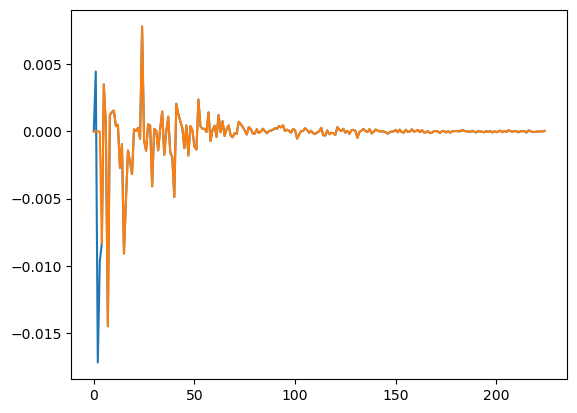

In [28]:
hks_coeffs = m.compute_hks_for_new_times(new_ts=[4.0], coeffs=True)
hks_coeffs_cut0 = zero_low_l_modes(hks_coeffs, 0)
hks_coeffs_cut1 = zero_low_l_modes(hks_coeffs, 1)

plt.plot(hks_coeffs_cut0)
plt.plot(hks_coeffs_cut1)

In [29]:
hks_cut0 = m.reconstruct_from_coeffs(hks_coeffs_cut0, lmax=15)
hks_cut1 = m.reconstruct_from_coeffs(hks_coeffs_cut1, lmax=15)

fig = go.Figure(data=[
    go.Mesh3d(
        x=m.v[:,0], y=m.v[:,1], z=m.v[:,2],
        i=m.f[:,0], j=m.f[:,1], k=m.f[:,2],
        intensity=hks_cut1,
        colorscale='Viridis',
        showscale=True,   # adds colorbar
        name="Surface"
    )
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    title="Heat kernel signature with low spectral modes removed"
)

fig.show()

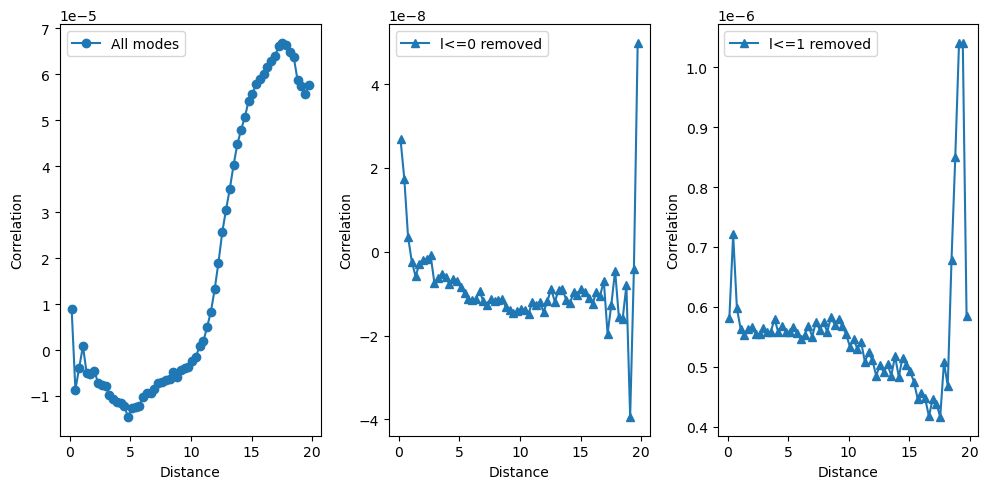

In [30]:
C_hks_cut0, N_hks_cut0 = accumulate_correlations_from_bins(bins_dist_equal, hks_cut0) # compute equal weighted correlations
C_hks_cut1, N_hks_cut1 = accumulate_correlations_from_bins(bins_dist_equal, hks_cut1) # compute equal weighted correlations


mean_eq_cut0 = np.nanmean(hks_cut0, axis=0)   # shape (F,)
mean_eq_cut1 = np.nanmean(hks_cut1, axis=0)   # shape (F,)
C_hks_cut0_conn = connected_from_C(C_hks_cut0, mean_eq_cut0)
C_hks_cut1_conn = connected_from_C(C_hks_cut1, mean_eq_cut1)

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.plot(bin_centers, Ce_hks_raw_conn[:,0,0], 'o-', label="All modes")
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.legend()

plt.subplot(1,3,2)
plt.plot(bin_centers, C_hks_cut0_conn[:,0,0], '^-', label="l<=0 removed")
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.legend()

plt.subplot(1,3,3)
plt.plot(bin_centers, C_hks_cut1_conn[:,0,0], '^-', label="l<=1 removed")
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.legend()

plt.tight_layout()
plt.show()